In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle

file_path = "/content/drive/MyDrive/AMC_Project/RML2016.10a_dict.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(type(data))
print(len(data))

<class 'dict'>
220


In [ ]:
print(list(data.keys())[:5])

[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]


In [ ]:
mods = sorted(set([key[0] for key in data.keys()]))

print("Number of modulation types:", len(mods))
print(mods)

Number of modulation types: 11
['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


In [ ]:
snrs = sorted(set([key[1] for key in data.keys()]))

print("Number of SNR levels:", len(snrs))
print(snrs)

Number of SNR levels: 20
[-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [ ]:
sample_key = list(data.keys())[0]

print("Sample key:", sample_key)
print("Shape:", data[sample_key].shape)

Sample key: ('QPSK', 2)
Shape: (1000, 2, 128)


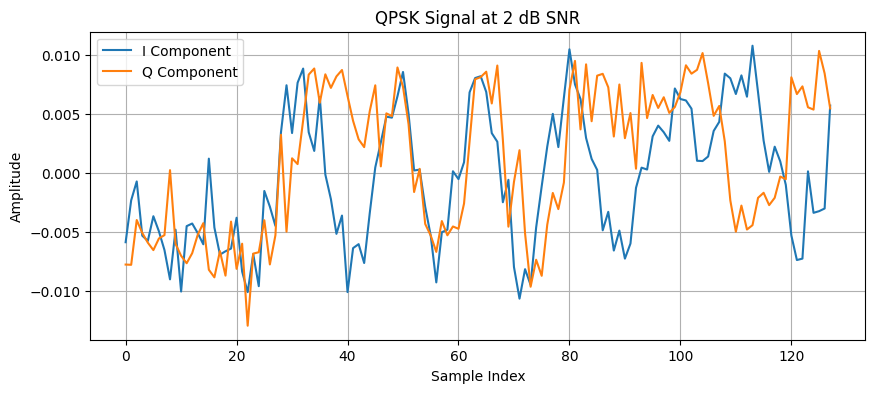

In [ ]:
import matplotlib.pyplot as plt

sample = data[('QPSK', 2)][0]

plt.figure(figsize=(10, 4))

plt.plot(sample[0], label='I Component')
plt.plot(sample[1], label='Q Component')

plt.title('QPSK Signal at 2 dB SNR')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
total_samples = 0

for key in data.keys():
    total_samples += data[key].shape[0]

print("Total samples:", total_samples)

Total samples: 220000


In [ ]:
import numpy as np

X = []
y = []

for mod, snr in data.keys():
    X.append(data[(mod, snr)])
    y.extend([mod] * data[(mod, snr)].shape[0])

X = np.vstack(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (220000, 2, 128)
y shape: (220000,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)
print("First 10 encoded labels:", y_encoded[:10])

Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']
First 10 encoded labels: [9 9 9 9 9 9 9 9 9 9]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (176000, 2, 128)
X_test shape: (44000, 2, 128)
y_train shape: (176000,)
y_test shape: (44000,)


In [ ]:
X_train = X_train.transpose(0, 2, 1)
X_test = X_test.transpose(0, 2, 1)

print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)

New X_train shape: (176000, 128, 2)
New X_test shape: (44000, 128, 2)


In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(encoder.classes_)

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (176000, 11)
y_test shape: (44000, 11)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, Flatten

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(128, 2)),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 518,219 (1.98 MB)

 Trainable params: 518,219 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.2169 - loss: 2.1050 - val_accuracy: 0.2866 - val_loss: 1.9313
Epoch 2/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2942 - loss: 1.9005 - val_accuracy: 0.3557 - val_loss: 1.7780
Epoch 3/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3323 - loss: 1.8066 - val_accuracy: 0.3795 - val_loss: 1.6908
Epoch 4/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3523 - loss: 1.7436 - val_accuracy: 0.3916 - val_loss: 1.6407
Epoch 5/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3679 - loss: 1.7009 - val_accuracy: 0.4075 - val_loss: 1.6044
Epoch 6/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3825 - loss: 1.6602 - val_accuracy: 0.4152 - val_loss: 1.5688
Epoch 7/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3922 - loss: 1.6295 - val_accuracy: 0.4343 - val_loss: 1.5122
Epoch 8/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3983 - loss: 1.5999 - val_accuracy:

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4624 - loss: 1.4274
Test Accuracy: 0.4624
Test Loss: 1.4274


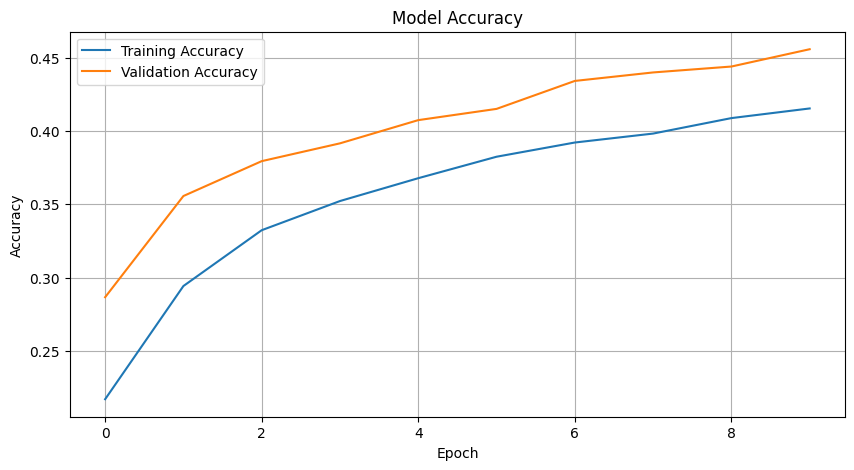

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
predictions = model.predict(X_test)

predicted_labels = predictions.argmax(axis=1)
true_labels = y_test.argmax(axis=1)

print("Predicted:", encoder.inverse_transform(predicted_labels[:10]))
print("Actual:   ", encoder.inverse_transform(true_labels[:10]))

1375/1375 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Predicted: ['PAM4' 'PAM4' 'QAM16' 'AM-SSB' 'AM-SSB' 'QAM64' 'AM-SSB' 'AM-SSB'
 'AM-DSB' 'AM-SSB']
Actual:    ['PAM4' 'PAM4' 'QAM16' 'AM-SSB' 'AM-SSB' 'QAM64' 'AM-DSB' 'CPFSK' 'AM-DSB'
 'GFSK']


<Figure size 1000x1000 with 0 Axes>

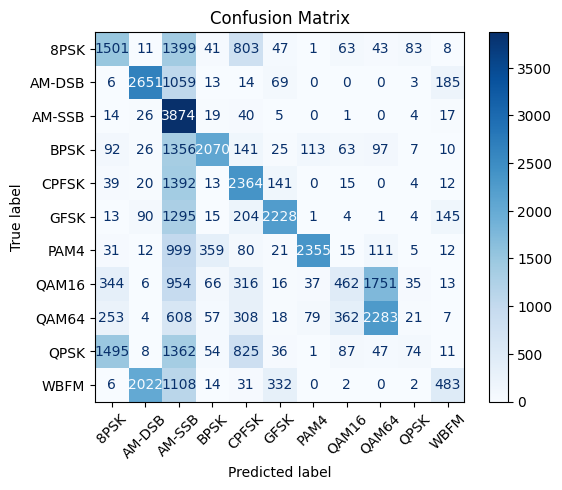

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save("amc_cnn_model.keras")